<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/AI_HW3_Classification_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание 3. Линейная классификация (base)**

### **Оценивание и штрафы**

С наступающим новым годом, друзья! Магистратура бежит быстро и мы бежим очень быстро, а зима — то время, когда хотелось бы бежать чуть медленнее. Поэтому это домашнее задание мы сделали сильно короче от его начальной версии!

Как всегда, каждая из задач имеет «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу — 10 баллов.

В задании две части:

- Часть 1: написание логистической регрессии своими руками — уверенны, логлосс вы уже знаете как свои пять пальцев.
- Часть 2: решение задачи классификации на текстах.

In [229]:
%pylab inline
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, auc, precision_recall_curve, accuracy_score
from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import hstack
import matplotlib.pyplot as plt




from sklearn.metrics import accuracy_score, roc_auc_score

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


C:\Users\Albert13\miniconda3\Lib\site-packages\IPython\core\magics\pylab.py:166: UserWarning: pylab import has clobbered these variables: ['hstack']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


# **Часть 1. Логистическая регрессия своими руками (5 баллов)**

Логистическая регрессия — безумно важная и удобная модель для понимания начальных концепций. Вы много практиковались с выведением формулы градиента логлосса, шага спуска, а в прошлом дз сделали SGD. Давайте сделаем ещё шаг вперед — и реализуем логистическую регрессию своими руками.

На практике, часто хватает алгоритмов из коробки. Но иногда очень удобно сделать свой алгоритм.

## **Теоретическая сноска: почему LogLoss'а так много**

Почти наверное (в математике это значит, во всех случаях, кроме множества размером 0) логлосс набил оскомину за несколько заданий. Давайте посмотрим на него ещё раз:

В логистической регрессии функция потерь

$$\text{LogLoss}(y, \hat{p}) = -\left(y\log \hat{p} + (1-y)\log (1-\hat{p})\right)$$

Зачем мы так долго с ней возимся?

#### **Пункт 1.**
Во-первых, это **следствие максимизации правдоподобия** при биномиальной модели.

Если считать, что целевая переменная (Y\in{0,1}) распределена как

$$P(Y=1 \mid x) = \hat{p}(x), \qquad P(Y=0\mid x) = 1-\hat{p}(x),$$
то правдоподобие выборки ( (x_i, y_i) )\ равно
$$L = \prod_{i=1}^n \hat{p}_i^{y_i}(1-\hat{p}_i)^{1-y_i}.$$

Максимизация $\log L$ эквивалентна минимизации LogLoss.
Таким образом, LogLoss — **единственная функция потерь, полностью согласованная с вероятностной моделью логистической регрессии**.

#### **Пункт 2.**

Во-вторых, логлосс поможет нам в будущем понять другие функции потерь. Так, например LogLoss является частным случаем **кросс-энтропии между истинным распределением и предсказанным**.

Для двух распределений $p$ (истинного) и $q$ (предсказанного) кросс-энтропия определяется как

$$H(p,q) = -\sum_{k} p(k)\log q(k).$$

В бинарном случае истинное распределение дискретно:

$$p = (y, 1-y), \qquad q = (\hat{p}, 1-\hat{p}),$$
и подстановка даёт

$$H(p,q) = -\left[y\log \hat{p} + (1-y)\log (1-\hat{p})\right] = \text{LogLoss}.$$


В общем, любим, жалуем и реализуем.




### **Задание 1. Реализуйте класс логистической регрессии, обучаемой с помощью:**

**Задание 1.1 (1.5 балла). Градиентного спуска**

**Задание 1.2 (1.5 балла). Стохастического градиентного спуска**

До этого вы писали код без ограничений. Здесь же необходимо соблюдать следующие условия:

- Градиентный спуск необходимо записать в векторном виде;
- Циклы средствами python допускается использовать только для итераций градиентного спуска;

**Класс градиентного спуска должен:**
- В качестве критерия останова использовать (одновременно):
  - проверку на евклидову норму разности весов на двух соседних итерациях задаваемого параметром `tolerance`;
  - достижение максимального числа итераций, задаваемого параметром `max_iter`.
- Обладать атрибутом `loss_history`. В нём после вызова метода fit должны содержаться значения функции потерь для всех итераций, начиная с первой (до совершения первого шага по антиградиенту). Данный атрибут необходим, чтобы проследить, что оптимизационный процесс действительно сходится;
- Инициализировать веса случайным образом или нулевым вектором (на ваш выбор).

Полезно [почитать](https://scikit-learn.org/stable/developers/develop.html).

**Шаблон класса описан ниже, вам нужно реализовать каждую из заготовленных функций.**

**ВАЖНО!** Мы заполняем данный шаблон, даже если он нам не нравится. Менять структуру класса и писать по-своему запрещено - за это будут сняты баллы.

In [230]:
import numpy as np
from sklearn.base import BaseEstimator

class LogReg(BaseEstimator):
    def __init__(self, gd_type='stochastic',
                 tolerance=1e-4, max_iter=1000, w0=None, eta=1e-2):
        """
        gd_type: 'full' or 'stochastic'
        tolerance: for stopping gradient descent
        max_iter: maximum number of steps in gradient descent
        w0: np.array of shape (d) — init weights
        eta: learning rate
        """
        self.gd_type = gd_type
        self.tolerance = tolerance
        self.max_iter = max_iter
        self.w0 = w0
        self.w = None
        self.eta = eta
        self.loss_history = []

    def fit(self, X, y):
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: self
        """
        
        if self.w0 is None:
            self.w = np.zeros(X.shape[1])
        else:
            self.w = self.w0.copy()
            
        self.loss_history.append(self.calc_loss(X, y))
                
        for i in range(self.max_iter):
            if self.gd_type == 'full':
                w_grad = self.calc_gradient(X, y)
                
            elif self.gd_type == 'stochastic':
                idx = np.random.randint(0, len(y)) 
                X_batch = X[idx:idx+1]
                y_batch = y[idx:idx+1]
                w_grad = self.calc_gradient(X_batch, y_batch)
                if np.linalg.norm(w_grad) < self.tolerance:
                    break

            self.w = self.w - self.eta * w_grad
            self.loss_history.append(self.calc_loss(X, y))
            
        return self

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def predict_proba(self, X):
        if self.w is None:
            raise Exception('Not trained yet')

        # Ваш код здесь
        z = X @ self.w
        return self.sigmoid(z)
        


    def predict(self, X):
        if self.w is None:
            raise Exception('Not trained yet')
          # Ваш код здесь
        proba = self.predict_proba(X)
        return (proba>0.5).astype(int)


    def calc_gradient(self, X, y):
        """
        X: np.array of shape (ell, d) (ell can be equal to 1 if stochastic)
        y: np.array of shape (ell)
        ---
        output: np.array of shape (d)
        """
        # В качестве лосса тут рассматриваем LogLoss !

        # Ваш код здесь
        
        z = X @ self.w
        y_pred = self.sigmoid(z)
        
        w_grad = (1/len(y)) * (X.T @ (y_pred - y))
        
        return w_grad


    def calc_loss(self, X, y):
        """
        X: np.array of shape (ell, d)
        y: np.array of shape (ell)
        ---
        output: float
        """
        y_pred_value =  X @ self.w
        y_pred = self.sigmoid(y_pred_value)
        log_loss_value = - (1 / len(y)) * (
            np.dot(y, np.log(y_pred)) + 
            np.dot((1 - y), np.log(1 - y_pred))
        )
        return log_loss_value


Теперь проверим работу вашего класса на синтетических данных.

In [231]:
from sklearn.preprocessing import StandardScaler

X, y = make_classification(
    n_samples=100000, n_features=20, n_informative=2,
    random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### **Задание 2 (0.6 балла)**

Теперь давайте тестировать модель.
1. Обучите свою логистическую регрессию на синтетических данных (0.2 балла) — на полном GD и SGD;
2. Cравните результат с моделью из библиотеки. Посчитайте roc-auc, accuracy, постройте ROC и PR кривые. , оцените разницу в производительности моделей по метрикам качества. Ответьте на вопросы:
- Какая показывает лучший результат? Почему?
- Есть ли что-то в модели из коробки, что по умолчанию делает её не равной вашей модели? Для ответа на этот вопрос вам может пригодитться [документация](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). Её мы изучаем всегда, чтобы понимать тонкости реализации какого-либо метода в библиотеке. (0.4 балла)

In [232]:
lr_sgd = LogReg(gd_type='stochastic')
lr_sgd.fit(X_train, y_train)

lr_full = LogReg(gd_type='full')
lr_full.fit(X_train, y_train)


,gd_type,'full'
,tolerance,0.0001
,max_iter,1000
,w0,None
,eta,0.01


Accuracy sto: 0.8628000
Roc-Auc sto: 0.8628375
Accuracy full: 0.8660333
Roc-Auc full: 0.8660576
Accuracy Sklearn: 0.8681000
Roc-Auc Sklearn: 0.8681011


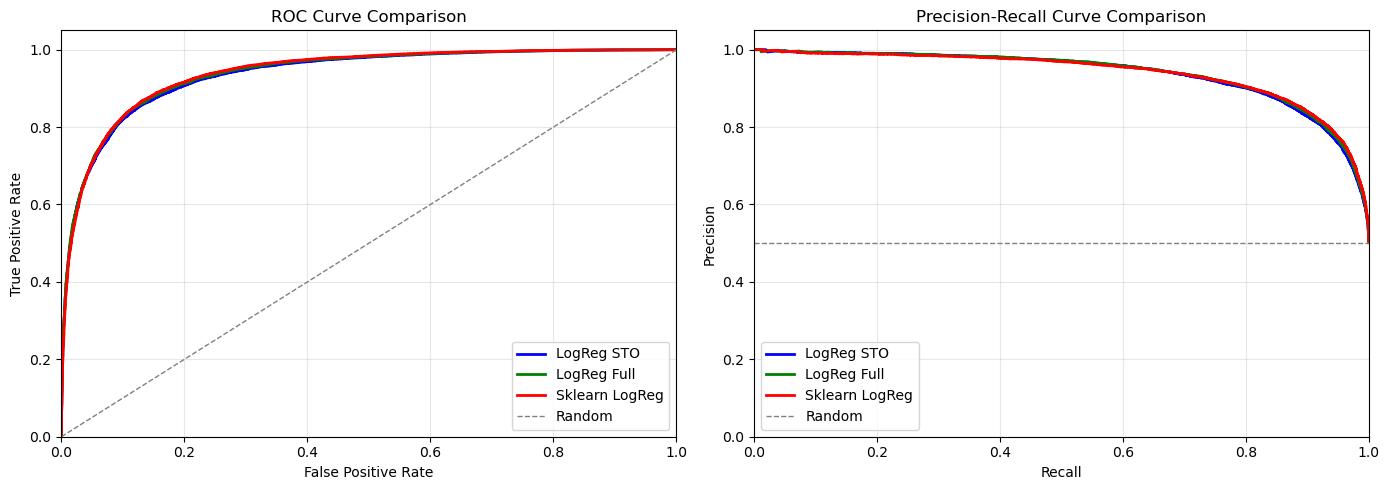

In [233]:
# Ваш код здесь

y_proba_sto = lr_sgd.predict_proba(X_test) 
y_pred_sto = lr_sgd.predict(X_test)  

y_proba_full = lr_full.predict_proba(X_test)  
y_pred_full = lr_full.predict(X_test)  

lr_sklearn = LogisticRegression(random_state=42, max_iter=1000)
lr_sklearn.fit(X_train, y_train)

y_proba_sklearn = lr_sklearn.predict_proba(X_test)  
y_pred_sklearn = lr_sklearn.predict(X_test)  

acc_sto = accuracy_score(y_test, y_pred_sto)
roc_auc_sto = roc_auc_score(y_test, y_pred_sto)
print(f"Accuracy sto: {acc_sto:.7f}")
print(f"Roc-Auc sto: {roc_auc_sto:.7f}")

acc_full = accuracy_score(y_test, y_pred_full)
roc_auc_full= roc_auc_score(y_test, y_pred_full)
print(f"Accuracy full: {acc_full:.7f}")
print(f"Roc-Auc full: {roc_auc_full:.7f}")


acc_sk_learn = accuracy_score(y_test, y_pred_sklearn)
roc_auc_sk_learn= roc_auc_score(y_test, y_pred_sklearn)
print(f"Accuracy Sklearn: {acc_sk_learn:.7f}")
print(f"Roc-Auc Sklearn: {roc_auc_sk_learn:.7f}")


#ГРАФИКИ ЧЕРТИЛ С LLM - ЧТОБЫ ОНИ БЫЛИ КРАСИВЫМИ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr_sto, tpr_sto, _ = roc_curve(y_test, y_proba_sto)  
roc_auc_sto = auc(fpr_sto, tpr_sto)

fpr_full, tpr_full, _ = roc_curve(y_test, y_proba_full)  
roc_auc_full = auc(fpr_full, tpr_full)

fpr_sklearn, tpr_sklearn, _ = roc_curve(y_test, y_proba_sklearn[:, 1])  
roc_auc_sklearn = auc(fpr_sklearn, tpr_sklearn)

axes[0].plot(fpr_sto, tpr_sto, color='blue', lw=2, 
             label=f'LogReg STO')
axes[0].plot(fpr_full, tpr_full, color='green', lw=2, 
             label=f'LogReg Full')
axes[0].plot(fpr_sklearn, tpr_sklearn, color='red', lw=2, 
             label=f'Sklearn LogReg')

axes[0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')

axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

precision_sto, recall_sto, _ = precision_recall_curve(y_test, y_proba_sto)
pr_auc_sto = auc(recall_sto, precision_sto)

precision_full, recall_full, _ = precision_recall_curve(y_test, y_proba_full)
pr_auc_full = auc(recall_full, precision_full)

precision_sklearn, recall_sklearn, _ = precision_recall_curve(y_test, y_proba_sklearn[:, 1])
pr_auc_sklearn = auc(recall_sklearn, precision_sklearn)

axes[1].plot(recall_sto, precision_sto, color='blue', lw=2,
             label=f'LogReg STO')
axes[1].plot(recall_full, precision_full, color='green', lw=2,
             label=f'LogReg Full')
axes[1].plot(recall_sklearn, precision_sklearn, color='red', lw=2,
             label=f'Sklearn LogReg')

if len(y_test) > 0:
    positive_ratio = y_test.mean()  
    axes[1].axhline(y=positive_ratio, color='gray', lw=1, linestyle='--', 
                    label=f'Random')

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve Comparison')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Разница в метриках сравнительно небольшая, но в целом метрики у модели из коробки лучше.

1. Лучшие метрики показывает модель из коробки
2. Причины: в модели из коробки присутствует регуляризация, как мы видим L2 по умолчанию и вес C =0.1, более продвинутые алгоритмы оптимизации: sklearn использует L-BFGS, Newton-CG, автоматический подбор оптимального шага.

### **Задание 3 (0.4 балла)**

Для трех полученных моделей, визуализируйте прогнозы по данным на тестовой выборке. Для этого:
- получите прогнозы;
- сомжите данные, используя PCA. Не забудьте, что PCA полагает нулевое среднее и единичную дисперсию;
- покрасьте данные по прогнозам.

Как различаются графики для трёх моделей? И различаются ли?

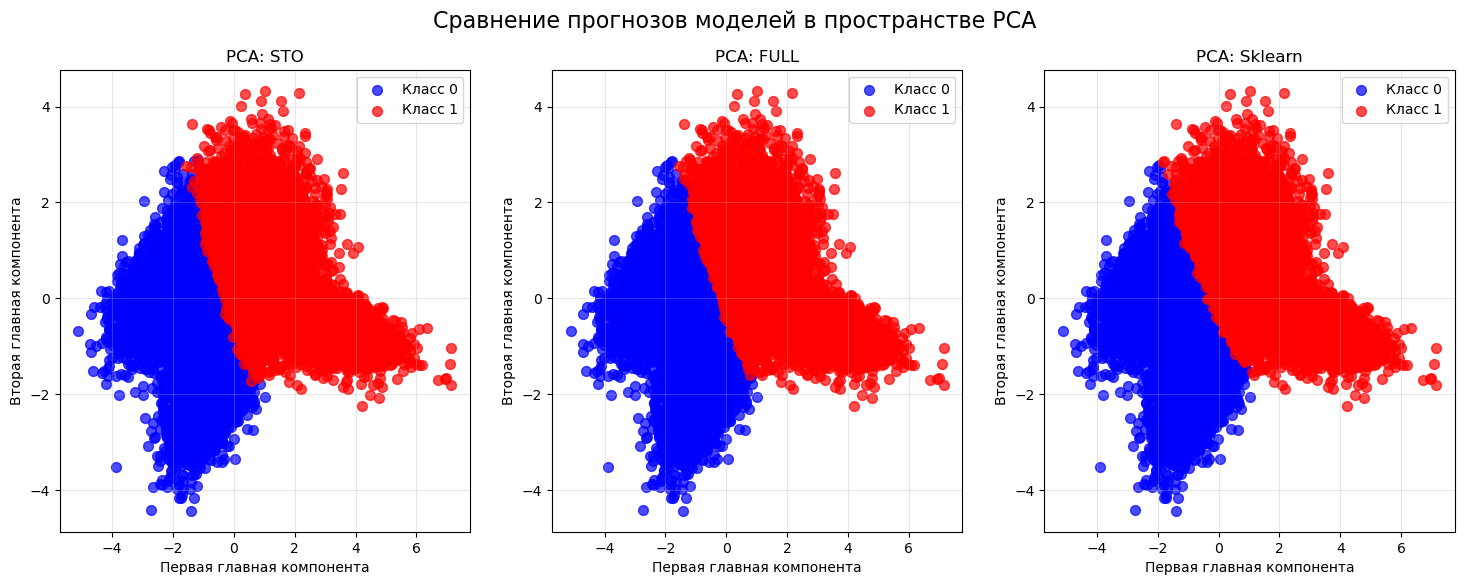

In [234]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)  

pca = PCA(n_components=2)  
X_test_pca = pca.fit_transform(X_test_scaled)  

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
model_names = ['STO', 'FULL', 'Sklearn']
predictions = [y_pred_sto, y_pred_full, y_pred_sklearn]


# ЧЕРТИЛ С ИСПОЛЬЗОВАНИЕМ LLM - БЫЛ НЕПОНЯТЕН ШАГ  X_test_pca[preds == 0] и X_test_pca[preds == 1], то есть как именно начертить все это. Думал, что должно быть на осях
for i, (name, preds) in enumerate(zip(model_names, predictions)):
    ax = axes[i]
    
    class_0 = X_test_pca[preds == 0]
    class_1 = X_test_pca[preds == 1]
    
    ax.scatter(class_0[:, 0], class_0[:, 1], 
               c='blue', label='Класс 0', alpha=0.7, s=50)
    ax.scatter(class_1[:, 0], class_1[:, 1],
               c='red', label='Класс 1', alpha=0.7, s=50)
    
    ax.set_title(f'PCA: {name}')
    ax.set_xlabel('Первая главная компонента')
    ax.set_ylabel('Вторая главная компонента')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Сравнение прогнозов моделей в пространстве PCA', fontsize=16)
plt.show()



# **Часть 2. Обучение моделей на текстовых данных. (5 баллов)**

 ### **Подготовка данных из реального мира.**

Ещё одна прелесть простых моделей — возможность решать с ними неструктурированные (изначально не табличные) задачи. Давайте посмотрим на это в действии на примере текстов.


Загрузите данные с конкурса  [Natural Language Processing with Disaster Tweets](https://www.kaggle.com/competitions/nlp-getting-started/data?select=train.csv) (вам нужна только обучающая выборка, файл `train.csv`). Задача состоит в определении постов, сообщающих о чрезвычайной ситуации. В рамках домашнего задания, этот набор данных будет отличным полем для тренировки в обработке признаков.

In [235]:
from sklearn.model_selection import train_test_split

PATH = 'train.csv'
data = pd.read_csv(PATH)

data.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


### **Задание 10. Базовая предобработка (1.5 балла).**

- Выведите на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их пустой строкой (0.2 балла).

In [236]:
print(data.isnull().sum())

data.fillna('', inplace=True)

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


- Проанализируйте количество уникальных значений в столбцах, опустив `text`. Сделайте выводы. (0.5 балла)

In [237]:
# Ваш код здесь, не забудьте выводы

data_without_text = data.drop(columns=['text'])
print(data_without_text.nunique())


id          7613
keyword      222
location    3342
target         2
dtype: int64


- Проанализируйте соотношение классов в целевой переменной. Какое оно? Выберите метрику, с помощью которой будете оценивать модель.  (0.5 балла)

In [238]:
# Ваш код здесь

count_true = (data_without_text['target'] == 1).sum()
count_false = (data_without_text['target'] == 0).sum()

ratio = count_true / count_false
rounded_ratio = round(ratio, 3)

print(rounded_ratio)

#Выберу accuracy исходя из предыдущих шагов и экспериментов, хорошая метрика для классификации, достаточно базовая


0.753


- Объедините все три текстовых столбца в один для baseline (вам поможет конкатенация строк) (0.3 балла)

In [239]:
# Ваш код здесь

data_new = data.copy()
data_new['full_text'] = data['text'] + data['keyword'] + data['location']

- Наконец, поделите данные на тренировочную и тестовую выборки. (0.2 балла)

In [240]:
X = data_new['full_text']
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### **Задание 11. Базовые модели. (1 балл).**

Данные, собираемые с сайтов, часто содержат мусор не информативный для моделей. Посмотрите, какого качества и насколько разнообразны данные здесь. Для этого:
- Примените CountVectorizer из sklearn к сырым даным. Какого размера получилась матрица? (0.3 балла)

In [241]:

# Ваш код здесь
vectorizer = CountVectorizer()
X_vect_train = vectorizer.fit_transform(X_train)
X_vect_test  = vectorizer.transform(X_test)

print("X_vect_train:",X_vect_train.shape)
print("X_vect_test:",X_vect_test.shape)



X_vect_train: (5329, 19948)
X_vect_test: (2284, 19948)


- Обучите логистическую регрессию на полученном наборе. Модель возьмите из библиотеки. Какое качество по выбранной вами метрике у модели получилось на тестовых данных? (0.3 балла)

In [242]:
# Ваш код здесь
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_vect_train, y_train)
y_pred = model.predict(X_vect_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.7f}")


Accuracy: 0.8029772


- Обучите SVC на тех же данных с гиперпараметрами по умолчанию. Измерьте качество на тестовых данных и опишите результат. Проанализируйте качество и скорость обучения.(0.4 балла)

In [243]:
# Ваш код здесь
model_svc = SVC(kernel='linear', random_state=42)
model_svc.fit(X_vect_train, y_train)
y_pred_svc = model_svc.predict(X_vect_test)

acc_svc = accuracy_score(y_test, y_pred_svc)
print(f"Accuracy svc: {acc_svc:.7f}")

Accuracy svc: 0.7767075


### **Задание 12. Улучшение базовых моделей за счет данных. (0.3 балла).**

- Подберите гиперпараметры CountVectorizer так, чтобы признаков было минимум в 4 раза меньше, чем объектов, а качество модели при этом изменилось не более чем на $\pm 0.07$. Опишите подобранные гиперпараметры и на что они влияют.

Обучайте и логистическую регрессию, и SVC.

In [244]:
# Ваш код здесь

vectorizer_new = CountVectorizer(
    max_features=5000, #максимальное количество признаков в матрице
    ngram_range=(1, 2), # использует 1 слово и здесь расширяем до 2 слов
    stop_words='english', # выкидывает неинформативные слова типо yes no if so
    max_df=0.8 #выкидываем слова, которые встречаются больше чем в 80 процентах объектах
)
X_vect_new_train = vectorizer_new.fit_transform(X_train)
X_vect_new_test  = vectorizer_new.transform(X_test)

print("X_vect_train:",X_vect_new_train.shape)
print("X_vect_test:",X_vect_new_test.shape)

X_vect_train: (5329, 5000)
X_vect_test: (2284, 5000)


In [245]:
# Ваш код здесь
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_vect_new_train, y_train)
y_pred_log = model.predict(X_vect_new_test)

acc_log = accuracy_score(y_test, y_pred_log)
print(f"Accuracy log: {acc_log:.7f}")

model_svc = SVC(kernel='linear', random_state=42)
model_svc.fit(X_vect_new_train, y_train)
y_pred_svc_new = model_svc.predict(X_vect_new_test)

acc_svc_new = accuracy_score(y_test, y_pred_svc_new)
print(f"Accuracy svc new: {acc_svc_new:.7f}")


Accuracy log: 0.7885289
Accuracy svc new: 0.7683888


### **Задание 13. Улучшение базовых моделей за счет данных 2. (0.7 балла).**

В первом пункте мы склеили все строки в одну. Но можно было бы поступить иначе — и получить категории из `'keyword', 'location'`. Протестируйте такой подход на обеих моделях и замерьте качество. Улучшает ли это результат?

По итогу это никак не улучшает результат, у нас не так много ключевых слов, локаций достаточно. Видимо, для получения самой важной выжимки информации лучше все это объединить - потому что в keyword и location есть пустые строки, которые ухудшают прогноз, а если мы делаем full_text - то по важности эти keyword и location, и так попадут в матрицу признаков.

In [253]:
# Ваш код здесь
X = data[['text', 'keyword', 'location']]  
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

x_text_train = vectorizer_new.fit_transform(X_train['text'])
x_text_test = vectorizer_new.transform(X_test['text'])

x_key_train = vectorizer_new.fit_transform(X_train['keyword'])
x_key_test = vectorizer_new.transform(X_test['keyword'])

x_loc_train = vectorizer_new.fit_transform(X_train['location'])
x_loc_test = vectorizer_new.transform(X_test['location'])

X_train_log = hstack([x_text_train, x_key_train, x_loc_train])
X_test_log = hstack([x_text_test, x_key_test, x_loc_test])

model_log = LogisticRegression(max_iter=1000, random_state=42)
model_log.fit(X_train_log, y_train)
y_pred_log = model_log.predict(X_test_log)

acc_log_features = accuracy_score(y_test, y_pred_log)
print(f"Accuracy log with features: {acc_log_features:.7f}")


model_svc_features = SVC(kernel='linear', random_state=42)
model_svc_features.fit(X_train_log, y_train)
y_pred_svc = model_svc_features.predict(X_test_log)

acc_svc_features = accuracy_score(y_test, y_pred_svc)
print(f"Accuracy svc with features: {acc_svc_features:.7f}")


Accuracy log with features: 0.7950963
Accuracy svc with features: 0.7661996


### **Задание 13. Улучшение базовых моделей путем подбора гиперпараметров. (1 балл).**
- Попробуйте подбирать разные гиперпараметры для логистической регрессии. Опишите подбираемые гиперапарметры и ваши результаты (0.5 балла)

In [247]:
# Ваш код здесь
model_log_best = LogisticRegression(
    penalty='l2',
    solver='liblinear',
    C=0.3,
    max_iter=1000, 
    random_state=42)

# ПОДБИРАЛ СНАЧАЛА ПЕНАЛЬТИ И C - для регуляризации, после 0.3 качество уже падает - затем выбрал solver, шагов в 1000 итераций я посчитал достаточным


model_log_best.fit(X_vect_train, y_train)
y_pred_log_best = model_log_best.predict(X_vect_test)

acc_log_features_best = accuracy_score(y_test, y_pred_log_best)
print(f"Accuracy log best with features: {acc_log_features_best:.7f}")


Accuracy log best with features: 0.8139229


- Попробуйте подбирать разные гиперпараметры для модели SVC. Опишите подбираемые гиперапарметры и ваши результаты (0.5 балла)

In [248]:
# Ваш код здесь

model_svc_best = SVC(
    C=0.8,           
    kernel='rbf',  
    gamma=0.07,
    random_state=42
)

#Подбирал параметры регуляризации вручную - остановился на 0.8, качество после 0.8 ухудшалось. Ядро выбрал - rbf, тип ядра для нелинейного преобразования данных, взял потому что качество улучшилось = прочитал что они и выдают качество более хорошее, чем линейные ядра. Gamma подобрал тоже вручную, взял 0.1 - качество ухудшалось, подбирал в более маленьких шагах.

model_svc_best.fit(X_vect_train, y_train)

y_pred_svc = model_svc_best.predict(X_vect_test)
acc_svc = accuracy_score(y_test, y_pred_svc)

print(f"Accuracy svc best with features: {acc_svc:.7f}")

Accuracy svc best with features: 0.7924694


Разделение по фичам - не помогло, качество стало хуже. Возможно здесь логика в том, что объединив все в 1 текст и векторизовав - мы получаем самую важную информацию из всех текстовых признаков, а когда разделяем оставляем место для неважной информации. На 5000 тысячах признаков - качество ухудшилось, теряем важную информацию выкидывая признаки. 

Лучшее качество получили при подборе гиперпараметров вручную - в среднем на 0.02-0.03 улучшается качество модели с ними. Регуляризация добавляет качество видимо на каких-то случаях, где веса признаков получились достаточно большими, но видимо таких весов не так много, раз качество улучшилось не прям сильно. Также в SVC добавили нелинейное ядро, которое в большинстве случаев лучше, чем линейное.

### **Задание 14. (0.5 балла)**

Оформите два [пайплайна](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html):
- для модели регрессии
- для SVC модели

в пайплайн должны входить предобработка сырого датасета и обучение модели.

In [251]:
# Ваш код здесь
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin


class Preprocess(BaseEstimator, TransformerMixin):
    def __init__(self, text_col = 'text', keyword_col = 'keyword', location_col = 'location'):
        self.text_col = text_col
        self.keyword_col = keyword_col
        self.location_col = location_col
        self.vectorizer = CountVectorizer()
        
    def fit(self, X, y):
        full_text = X[self.text_col].fillna('') + ' ' + \
                     X[self.keyword_col].fillna('') + ' ' + \
                     X[self.location_col].fillna('')
        self.vectorizer.fit(full_text)
        return self
    
    def transform(self, X):
        full_text = X[self.text_col].fillna('') + ' ' + \
                     X[self.keyword_col].fillna('') + ' ' + \
                     X[self.location_col].fillna('')
        X_vectorized = self.vectorizer.transform(full_text)
        return X_vectorized
        
   
    

pipeline_logreg = Pipeline([
    ('preprocessor', Preprocess()),
    ('classifier', LogisticRegression())
])

pipeline_svc = Pipeline([
    ('preprocessor', Preprocess()),
    ('classifier', SVC())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

pipeline_logreg.fit(X_train, y_train)
y_pred_pipe_log = pipeline_logreg.predict(X_test)

acc_pred_pipe_log = accuracy_score(y_test, y_pred_pipe_log)

print(f"Accuracy pipeline log best with features: {acc_pred_pipe_log:.7f}")

pipeline_svc.fit(X_train, y_train)
y_pred_pipe_svc = pipeline_svc.predict(X_test)

acc_pred_pipe_svc = accuracy_score(y_test, y_pred_pipe_svc)

print(f"Accuracy pipeline svc best with features: {acc_pred_pipe_svc:.7f}")


Accuracy pipeline log best with features: 0.7994746
Accuracy pipeline svc best with features: 0.8047285


**Опишите общие мысли о работе. Это место для вашей рефлексии, не обязательное, но полезное.**  🐤

Достаточно полезная домашняя работа, в годовом проекте мы как раз использовали подход с объединением признаков текстовых в один большой текстовый признак.
Единственное, во всей этой лог регрессии - не совсем понятно как лучше выбирать метрику - потому что может это интуитивно или конкретно тут на наших датасетах - но логически подходит точность, хотя там метрик куча.